# Banking Customer Campaign Performance Analytics

## End-to-End Data Analyst Project for Banking Decision Support

---

**Author:** Chanez Benidir  
**Business Context:** Retail banking customer campaign performance analysis  
**Dataset:** Bank Marketing Dataset  
**Objective:** Analyze customer campaign performance, define business KPIs, identify high-value segments, simulate Test & Learn analysis, and generate automated reporting outputs.

---

## Table of Contents

1. Project Setup & Libraries  
2. Data Loading & Initial Understanding  
3. Data Quality Assessment  
4. Business Variable Understanding  
5. KPI Engineering  
6. Exploratory Data Analysis  
7. Customer Segmentation Analysis  
8. Campaign Performance Analysis  
9. Test & Learn / A-B Test Simulation  
10. Business Recommendations  
11. Automated HTML Dashboard  
12. Automated Excel KPI Report  
13. Final Executive Summary  

---

## Project Goal

This project aims to support banking business teams in understanding campaign performance and improving customer targeting.

The analysis focuses on:

- customer profile analysis;
- campaign conversion performance;
- KPI monitoring;
- high-performing customer segments;
- campaign efficiency;
- Test & Learn methodology;
- business recommendations for marketing and commercial teams.

In [1]:
# ============================================================
# 1. PROJECT SETUP AND LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Project directories
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"
REPORTS_DIR = PROJECT_ROOT / "reports"
SCREENSHOTS_DIR = PROJECT_ROOT / "screenshots"

# Create output folders if they do not exist
for directory in [PROCESSED_DATA_DIR, DASHBOARD_DIR, REPORTS_DIR, SCREENSHOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Libraries imported successfully")
print("Project directories")
print("Raw data       :", RAW_DATA_DIR)
print("Processed data :", PROCESSED_DATA_DIR)
print("Dashboard      :", DASHBOARD_DIR)
print("Reports        :", REPORTS_DIR)
print("Screenshots    :", SCREENSHOTS_DIR)

Libraries imported successfully
Project directories
Raw data       : ..\data\raw
Processed data : ..\data\processed
Dashboard      : ..\dashboard
Reports        : ..\reports
Screenshots    : ..\screenshots


In [2]:
# ============================================================
# 2. RAW DATA FILE DETECTION
# ============================================================

raw_files = list(RAW_DATA_DIR.iterdir())

print(f"Number of raw files detected: {len(raw_files)}")

for file in raw_files:
    print("-", file.name)

Number of raw files detected: 1
- bank-full.csv


In [4]:
# ============================================================
# 3. DATA LOADING
# ============================================================

possible_files = [
    RAW_DATA_DIR / "bank-full.csv",
    RAW_DATA_DIR / "bank-full",
    RAW_DATA_DIR / "bank.csv",
    RAW_DATA_DIR / "bank"
]

data_path = None

for file_path in possible_files:
    if file_path.exists():
        data_path = file_path
        break

if data_path is None:
    raise FileNotFoundError(
        "No bank dataset found. Please make sure bank-full.csv is placed inside data/raw/."
    )

print("Selected data file:", data_path.name)

bank_data = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully")
print("Dataset shape:", bank_data.shape)

display(bank_data.head())

Selected data file: bank-full.csv
Dataset loaded successfully
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
# ============================================================
# 4. INITIAL DATA STRUCTURE
# ============================================================

print("Columns:")
print(bank_data.columns.tolist())

print("\nDataset information:")
bank_data.info()

print("\nTarget distribution:")
display(bank_data["y"].value_counts())

print("\nTarget percentage:")
display((bank_data["y"].value_counts(normalize=True) * 100).round(2))

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-nu

y
no     39922
yes     5289
Name: count, dtype: int64


Target percentage:


y
no    88.3000
yes   11.7000
Name: proportion, dtype: float64

# 3. Data Quality Assessment

This section evaluates the quality of the banking campaign dataset before creating KPIs and business insights.

The objective is to check:

- missing values;
- duplicated rows;
- unknown categorical values;
- numerical variable distributions;
- target quality;
- potential data quality issues.

In [6]:
# ============================================================
# 5. DATA QUALITY OVERVIEW
# ============================================================

print("=" * 70)
print("DATA QUALITY OVERVIEW")
print("=" * 70)

# Basic shape
print("Dataset shape:", bank_data.shape)

# Missing values
missing_values = bank_data.isnull().sum()
missing_percentage = (bank_data.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

print("\nMissing values report:")
display(missing_report)

# Duplicate rows
duplicate_count = bank_data.duplicated().sum()
duplicate_percentage = round(duplicate_count / len(bank_data) * 100, 2)

print("\nDuplicate rows:")
print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:", duplicate_percentage, "%")

# Data types
dtype_report = pd.DataFrame({
    "Column": bank_data.columns,
    "Data_Type": bank_data.dtypes.astype(str).values,
    "Unique_Values": bank_data.nunique().values
})

print("\nData types and unique values:")
display(dtype_report)

DATA QUALITY OVERVIEW
Dataset shape: (45211, 17)

Missing values report:


,Missing_Count,Missing_Percentage
age,0,0.0000
job,0,0.0000
marital,0,0.0000
education,0,0.0000
default,0,0.0000
balance,0,0.0000
housing,0,0.0000
loan,0,0.0000
contact,0,0.0000
day,0,0.0000



Duplicate rows:
Number of duplicate rows: 0
Percentage of duplicate rows: 0.0 %

Data types and unique values:


,Column,Data_Type,Unique_Values
0,age,int64,77
1,job,object,12
2,marital,object,3
3,education,object,4
4,default,object,2
5,balance,int64,7168
6,housing,object,2
7,loan,object,2
8,contact,object,3
9,day,int64,31


In [7]:
# ============================================================
# 6. UNKNOWN VALUES ANALYSIS
# ============================================================

categorical_columns = bank_data.select_dtypes(include="object").columns.tolist()

unknown_summary = []

for col in categorical_columns:
    unknown_count = (bank_data[col] == "unknown").sum()
    unknown_percentage = round(unknown_count / len(bank_data) * 100, 2)
    
    unknown_summary.append({
        "Column": col,
        "Unknown_Count": unknown_count,
        "Unknown_Percentage": unknown_percentage
    })

unknown_report = pd.DataFrame(unknown_summary).sort_values(
    by="Unknown_Percentage",
    ascending=False
)

print("Unknown values report:")
display(unknown_report)

Unknown values report:


,Column,Unknown_Count,Unknown_Percentage
8,poutcome,36959,81.7500
6,contact,13020,28.8000
2,education,1857,4.1100
0,job,288,0.6400
1,marital,0,0.0000
3,default,0,0.0000
5,loan,0,0.0000
4,housing,0,0.0000
7,month,0,0.0000
9,y,0,0.0000


In [8]:
# ============================================================
# 7. NUMERICAL VARIABLES SUMMARY
# ============================================================

numeric_columns = bank_data.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

numeric_summary = bank_data[numeric_columns].describe().T

numeric_summary["range"] = numeric_summary["max"] - numeric_summary["min"]

display(numeric_summary)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


,count,mean,std,min,25%,50%,75%,max,range
age,"45,211.0000",40.9362,10.6188,18.0000,33.0000,39.0000,48.0000,95.0000,77.0000
balance,"45,211.0000","1,362.2721","3,044.7658","-8,019.0000",72.0000,448.0000,"1,428.0000","102,127.0000","110,146.0000"
day,"45,211.0000",15.8064,8.3225,1.0000,8.0000,16.0000,21.0000,31.0000,30.0000
duration,"45,211.0000",258.1631,257.5278,0.0000,103.0000,180.0000,319.0000,"4,918.0000","4,918.0000"
campaign,"45,211.0000",2.7638,3.0980,1.0000,1.0000,2.0000,3.0000,63.0000,62.0000
pdays,"45,211.0000",40.1978,100.1287,-1.0000,-1.0000,-1.0000,-1.0000,871.0000,872.0000
previous,"45,211.0000",0.5803,2.3034,0.0000,0.0000,0.0000,0.0000,275.0000,275.0000


In [9]:
# ============================================================
# 8. CATEGORICAL VARIABLES SUMMARY
# ============================================================

for col in categorical_columns:
    print("=" * 70)
    print(f"Column: {col}")
    print("=" * 70)
    
    value_counts = bank_data[col].value_counts()
    value_percentages = (bank_data[col].value_counts(normalize=True) * 100).round(2)
    
    summary = pd.DataFrame({
        "Count": value_counts,
        "Percentage": value_percentages
    })
    
    display(summary)

Column: job


,Count,Percentage
job,,
blue-collar,9732,21.5300
management,9458,20.9200
technician,7597,16.8000
admin.,5171,11.4400
services,4154,9.1900
retired,2264,5.0100
self-employed,1579,3.4900
entrepreneur,1487,3.2900
unemployed,1303,2.8800


Column: marital


,Count,Percentage
marital,,
married,27214,60.1900
single,12790,28.2900
divorced,5207,11.5200


Column: education


...

,Count,Percentage
month,,
may,13766,30.4500
jul,6895,15.2500
aug,6247,13.8200
jun,5341,11.8100
nov,3970,8.7800
apr,2932,6.4900
feb,2649,5.8600
jan,1403,3.1000
oct,738,1.6300


Column: poutcome


,Count,Percentage
poutcome,,
unknown,36959,81.7500
failure,4901,10.8400
other,1840,4.0700
success,1511,3.3400


Column: y


,Count,Percentage
y,,
no,39922,88.3000
yes,5289,11.7000


In [10]:
# ============================================================
# 9. CREATE CLEAN ANALYTICAL TARGET
# ============================================================

bank_df = bank_data.copy()

# Binary conversion target
bank_df["conversion"] = bank_df["y"].map({
    "yes": 1,
    "no": 0
})

# Conversion label
bank_df["conversion_label"] = bank_df["y"].map({
    "yes": "Converted",
    "no": "Not Converted"
})

print("Analytical target created successfully")

print("\nConversion distribution:")
display(bank_df["conversion_label"].value_counts())

print("\nConversion rate:")
conversion_rate = bank_df["conversion"].mean() * 100
print(f"{conversion_rate:.2f}%")

# Save initial processed dataset
processed_path = PROCESSED_DATA_DIR / "banking_campaign_processed_initial.csv"
bank_df.to_csv(processed_path, index=False)

print("\nProcessed initial dataset saved at:", processed_path)

Analytical target created successfully

Conversion distribution:


conversion_label
Not Converted    39922
Converted         5289
Name: count, dtype: int64


Conversion rate:
11.70%

Processed initial dataset saved at: ..\data\processed\banking_campaign_processed_initial.csv


# 4. KPI Engineering

This section creates analytical and business-oriented variables used to monitor banking campaign performance.

The objective is to transform raw customer and campaign data into interpretable KPIs such as:

- conversion rate;
- customer age groups;
- balance segments;
- campaign contact intensity;
- previous campaign exposure;
- loan profile;
- campaign performance indicators.

In [11]:
# ============================================================
# 10. KPI FEATURE ENGINEERING
# ============================================================

bank_kpi = bank_df.copy()

# ------------------------------------------------------------
# 1. Conversion target
# ------------------------------------------------------------

bank_kpi["conversion"] = bank_kpi["y"].map({
    "yes": 1,
    "no": 0
})

bank_kpi["conversion_label"] = bank_kpi["y"].map({
    "yes": "Converted",
    "no": "Not Converted"
})

# ------------------------------------------------------------
# 2. Age groups
# ------------------------------------------------------------

bank_kpi["age_group"] = pd.cut(
    bank_kpi["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

# ------------------------------------------------------------
# 3. Balance segments
# ------------------------------------------------------------

bank_kpi["balance_segment"] = pd.cut(
    bank_kpi["balance"],
    bins=[-np.inf, 0, 500, 2000, 5000, np.inf],
    labels=[
        "Negative or Zero Balance",
        "Low Balance",
        "Medium Balance",
        "High Balance",
        "Premium Balance"
    ]
)

# ------------------------------------------------------------
# 4. Campaign contact intensity
# ------------------------------------------------------------

bank_kpi["campaign_contact_group"] = pd.cut(
    bank_kpi["campaign"],
    bins=[0, 1, 2, 3, 5, np.inf],
    labels=[
        "1 contact",
        "2 contacts",
        "3 contacts",
        "4-5 contacts",
        "6+ contacts"
    ]
)

# ------------------------------------------------------------
# 5. Call duration groups
# ------------------------------------------------------------

bank_kpi["duration_group"] = pd.cut(
    bank_kpi["duration"],
    bins=[-1, 60, 180, 300, 600, np.inf],
    labels=[
        "0-60 sec",
        "61-180 sec",
        "181-300 sec",
        "301-600 sec",
        "600+ sec"
    ]
)

# ------------------------------------------------------------
# 6. Previous campaign exposure
# ------------------------------------------------------------

bank_kpi["previous_contact_flag"] = np.where(
    bank_kpi["previous"] > 0,
    "Previously Contacted",
    "Not Previously Contacted"
)

bank_kpi["pdays_status"] = np.where(
    bank_kpi["pdays"] == -1,
    "No Previous Contact",
    "Previous Contact Available"
)

# ------------------------------------------------------------
# 7. Loan profile
# ------------------------------------------------------------

def assign_loan_profile(row):
    if row["housing"] == "yes" and row["loan"] == "yes":
        return "Housing + Personal Loan"
    elif row["housing"] == "yes" and row["loan"] == "no":
        return "Housing Loan Only"
    elif row["housing"] == "no" and row["loan"] == "yes":
        return "Personal Loan Only"
    else:
        return "No Active Loan"

bank_kpi["loan_profile"] = bank_kpi.apply(assign_loan_profile, axis=1)

# ------------------------------------------------------------
# 8. Customer financial profile
# ------------------------------------------------------------

bank_kpi["financial_profile"] = (
    bank_kpi["balance_segment"].astype(str)
    + " | "
    + bank_kpi["loan_profile"].astype(str)
)

print("KPI features created successfully")
print("Dataset shape after KPI engineering:", bank_kpi.shape)

display(bank_kpi.head())

KPI features created successfully
Dataset shape after KPI engineering: (45211, 27)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,conversion,conversion_label,age_group,balance_segment,campaign_contact_group,duration_group,previous_contact_flag,pdays_status,loan_profile,financial_profile
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,Not Converted,56-65,High Balance,1 contact,181-300 sec,Not Previously Contacted,No Previous Contact,Housing Loan Only,High Balance | Housing Loan Only
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,Not Converted,36-45,Low Balance,1 contact,61-180 sec,Not Previously Contacted,No Previous Contact,Housing Loan Only,Low Balance | Housing Loan Only
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,Not Converted,26-35,Low Balance,1 contact,61-180 sec,Not Previously Contacted,No Previous Contact,Housing + Personal Loan,Low Balance | Housing + Personal Loan
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,Not Converted,46-55,Medium Balance,1 contact,61-180 sec,Not Previously Contacted,No Previous Contact,Housing Loan Only,Medium Balance | Housing Loan Only
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,Not Converted,26-35,Low Balance,1 contact,181-300 sec,Not Previously Contacted,No Previous Contact,No Active Loan,Low Balance | No Active Loan


In [12]:
# ============================================================
# 11. KPI FEATURE VALIDATION
# ============================================================

new_kpi_columns = [
    "conversion",
    "conversion_label",
    "age_group",
    "balance_segment",
    "campaign_contact_group",
    "duration_group",
    "previous_contact_flag",
    "pdays_status",
    "loan_profile",
    "financial_profile"
]

print("New KPI columns:")
print(new_kpi_columns)

print("\nMissing values in new KPI columns:")
display(bank_kpi[new_kpi_columns].isnull().sum())

print("\nAge group distribution:")
display(bank_kpi["age_group"].value_counts(dropna=False))

print("\nBalance segment distribution:")
display(bank_kpi["balance_segment"].value_counts(dropna=False))

print("\nCampaign contact group distribution:")
display(bank_kpi["campaign_contact_group"].value_counts(dropna=False))

print("\nLoan profile distribution:")
display(bank_kpi["loan_profile"].value_counts(dropna=False))

New KPI columns:
['conversion', 'conversion_label', 'age_group', 'balance_segment', 'campaign_contact_group', 'duration_group', 'previous_contact_flag', 'pdays_status', 'loan_profile', 'financial_profile']

Missing values in new KPI columns:


conversion                0
conversion_label          0
age_group                 0
balance_segment           0
campaign_contact_group    0
duration_group            0
previous_contact_flag     0
pdays_status              0
loan_profile              0
financial_profile         0
dtype: int64


Age group distribution:


age_group
26-35    15571
36-45    13856
46-55     9548
56-65     4149
18-25     1336
66+        751
Name: count, dtype: int64


Balance segment distribution:


balance_segment
Low Balance                 16385
Medium Balance              13045
Negative or Zero Balance     7280
High Balance                 5656
Premium Balance              2845
Name: count, dtype: int64


Campaign contact group distribution:


campaign_contact_group
1 contact       17544
2 contacts      12505
3 contacts       5521
4-5 contacts     5286
6+ contacts      4355
Name: count, dtype: int64


Loan profile distribution:


loan_profile
Housing Loan Only          20763
No Active Loan             17204
Housing + Personal Loan     4367
Personal Loan Only          2877
Name: count, dtype: int64

In [13]:
# ============================================================
# 12. GLOBAL BUSINESS KPIS
# ============================================================

total_clients = len(bank_kpi)
converted_clients = bank_kpi["conversion"].sum()
not_converted_clients = total_clients - converted_clients
conversion_rate = bank_kpi["conversion"].mean() * 100

average_balance = bank_kpi["balance"].mean()
median_balance = bank_kpi["balance"].median()

average_campaign_contacts = bank_kpi["campaign"].mean()
median_campaign_contacts = bank_kpi["campaign"].median()

average_call_duration = bank_kpi["duration"].mean()
median_call_duration = bank_kpi["duration"].median()

previously_contacted_rate = (
    (bank_kpi["previous_contact_flag"] == "Previously Contacted").mean() * 100
)

global_kpis = pd.DataFrame({
    "KPI": [
        "Total Clients",
        "Converted Clients",
        "Not Converted Clients",
        "Conversion Rate (%)",
        "Average Balance",
        "Median Balance",
        "Average Campaign Contacts",
        "Median Campaign Contacts",
        "Average Call Duration (sec)",
        "Median Call Duration (sec)",
        "Previously Contacted Clients (%)"
    ],
    "Value": [
        total_clients,
        converted_clients,
        not_converted_clients,
        round(conversion_rate, 2),
        round(average_balance, 2),
        round(median_balance, 2),
        round(average_campaign_contacts, 2),
        round(median_campaign_contacts, 2),
        round(average_call_duration, 2),
        round(median_call_duration, 2),
        round(previously_contacted_rate, 2)
    ]
})

print("Global business KPIs:")
display(global_kpis)

# Save global KPIs
global_kpis_path = REPORTS_DIR / "global_business_kpis.csv"
global_kpis.to_csv(global_kpis_path, index=False)

print("Global KPIs saved at:", global_kpis_path)

Global business KPIs:


,KPI,Value
0,Total Clients,"45,211.0000"
1,Converted Clients,"5,289.0000"
2,Not Converted Clients,"39,922.0000"
3,Conversion Rate (%),11.7000
4,Average Balance,"1,362.2700"
5,Median Balance,448.0000
6,Average Campaign Contacts,2.7600
7,Median Campaign Contacts,2.0000
8,Average Call Duration (sec),258.1600
9,Median Call Duration (sec),180.0000


Global KPIs saved at: ..\reports\global_business_kpis.csv


In [14]:
# ============================================================
# 13. SEGMENT PERFORMANCE FUNCTION
# ============================================================

def segment_performance(data, segment_column):
    """
    Calculates business performance KPIs by customer or campaign segment.
    """
    result = (
        data
        .groupby(segment_column, observed=False)
        .agg(
            Clients=("conversion", "count"),
            Converted_Clients=("conversion", "sum"),
            Conversion_Rate=("conversion", "mean"),
            Average_Balance=("balance", "mean"),
            Average_Campaign_Contacts=("campaign", "mean"),
            Average_Call_Duration=("duration", "mean")
        )
        .reset_index()
    )
    
    result["Conversion_Rate"] = (result["Conversion_Rate"] * 100).round(2)
    result["Average_Balance"] = result["Average_Balance"].round(2)
    result["Average_Campaign_Contacts"] = result["Average_Campaign_Contacts"].round(2)
    result["Average_Call_Duration"] = result["Average_Call_Duration"].round(2)
    
    result = result.sort_values(
        by="Conversion_Rate",
        ascending=False
    )
    
    return result

In [15]:
# ============================================================
# 14. BUSINESS SEGMENT PERFORMANCE TABLES
# ============================================================

segment_columns = [
    "age_group",
    "job",
    "marital",
    "education",
    "balance_segment",
    "housing",
    "loan",
    "loan_profile",
    "contact",
    "month",
    "campaign_contact_group",
    "previous_contact_flag",
    "poutcome"
]

segment_performance_tables = {}

for col in segment_columns:
    segment_performance_tables[col] = segment_performance(bank_kpi, col)

print("Segment performance tables created successfully")

print("\nPerformance by age group:")
display(segment_performance_tables["age_group"])

print("\nPerformance by job:")
display(segment_performance_tables["job"].head(10))

print("\nPerformance by balance segment:")
display(segment_performance_tables["balance_segment"])

print("\nPerformance by campaign contact group:")
display(segment_performance_tables["campaign_contact_group"])

print("\nPerformance by previous campaign outcome:")
display(segment_performance_tables["poutcome"])

Segment performance tables created successfully

Performance by age group:


,age_group,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
5,66+,751,320,42.6100,"2,822.0000",2.0300,331.5600
0,18-25,1336,320,23.9500,897.9700,2.3900,271.7700
4,56-65,4149,586,14.1200,"1,958.4600",2.7200,261.4500
1,26-35,15571,1869,12.0000,"1,147.2000",2.7300,263.4300
2,36-45,13856,1301,9.3900,"1,319.5800",2.8300,255.5700
3,46-55,9548,893,9.3500,"1,466.0600",2.8600,244.2200



Performance by job:


,job,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
8,student,938,269,28.6800,"1,388.0600",2.3000,246.6600
5,retired,2264,516,22.7900,"1,984.2200",2.3500,287.3600
10,unemployed,1303,202,15.5000,"1,521.7500",2.4300,288.5400
4,management,9458,1301,13.7600,"1,763.6200",2.8600,254.0000
0,admin.,5171,631,12.2000,"1,135.8400",2.5800,246.9000
6,self-employed,1579,187,11.8400,"1,647.9700",2.8500,268.1600
11,unknown,288,34,11.8100,"1,772.3600",3.3100,237.6100
9,technician,7597,840,11.0600,"1,252.6300",2.9100,252.9000
7,services,4154,369,8.8800,997.0900,2.7200,259.3200
3,housemaid,1240,109,8.7900,"1,392.4000",2.8200,245.8200



Performance by balance segment:


,balance_segment,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
3,High Balance,5656,968,17.1100,"3,139.5800",2.6300,273.3900
4,Premium Balance,2845,441,15.5000,"9,826.1100",2.6700,276.0500
2,Medium Balance,13045,1698,13.0200,"1,051.9500",2.6500,266.5600
1,Low Balance,16385,1680,10.2500,204.4900,2.8200,247.0900
0,Negative or Zero Balance,7280,502,6.9000,-164.3400,3.0000,249.2200



Performance by campaign contact group:


,campaign_contact_group,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
0,1 contact,17544,2561,14.6000,"1,415.0600",1.0000,261.0500
1,2 contacts,12505,1401,11.2000,"1,365.0100",2.0000,275.3300
2,3 contacts,5521,618,11.1900,"1,350.6200",3.0000,271.6400
3,4-5 contacts,5286,456,8.6300,"1,244.4100",4.3300,245.6400
4,6+ contacts,4355,253,5.8100,"1,299.5900",9.8600,195.3600



Performance by previous campaign outcome:


,poutcome,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
2,success,1511,978,64.7300,"1,939.3000",1.8100,316.8700
1,other,1840,307,16.6800,"1,487.4100",2.4600,255.7200
0,failure,4901,618,12.6100,"1,465.8100",1.9800,244.1900
3,unknown,36959,3386,9.1600,"1,318.7200",2.9200,257.7400


In [16]:
# ============================================================
# 15. SAVE KPI DATASETS
# ============================================================

# Save enriched dataset
processed_kpi_path = PROCESSED_DATA_DIR / "banking_campaign_kpi_enriched.csv"
bank_kpi.to_csv(processed_kpi_path, index=False)

print("KPI enriched dataset saved at:", processed_kpi_path)

# Save each segment performance table
for segment_name, table in segment_performance_tables.items():
    file_name = f"segment_performance_by_{segment_name}.csv"
    output_path = REPORTS_DIR / file_name
    table.to_csv(output_path, index=False)

print("Segment performance reports saved in:", REPORTS_DIR)

KPI enriched dataset saved at: ..\data\processed\banking_campaign_kpi_enriched.csv
Segment performance reports saved in: ..\reports


# 5. Exploratory Data Analysis

This section visualizes the main business KPIs and campaign performance indicators.

The objective is to identify:

- overall campaign conversion;
- high-performing customer segments;
- campaign fatigue effects;
- previous campaign impact;
- financial profile influence;
- actionable insights for banking decision-makers.

In [18]:
# ============================================================
# 16. VISUALIZATION STYLE
# ============================================================

sns.set_theme(style="whitegrid")

FIGURES_DIR = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_current_figure(filename):
    """
    Save current matplotlib figure into reports/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Figure saved: {output_path}")

Figure saved: ..\reports\figures\01_global_conversion_distribution.png


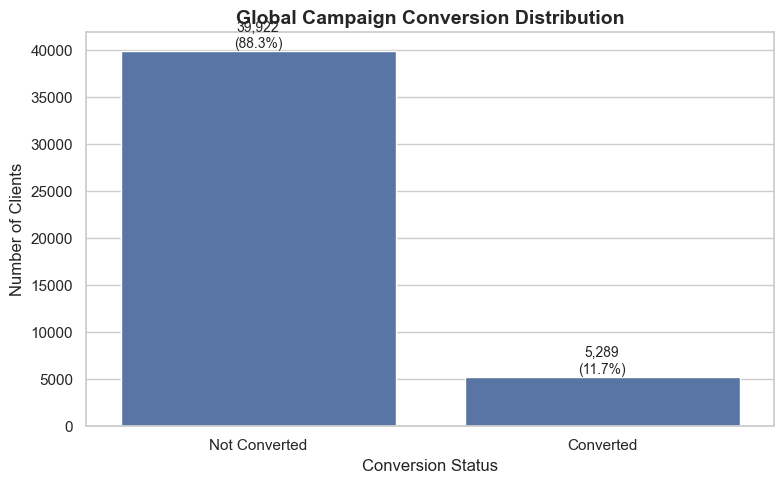

In [19]:
# ============================================================
# 17. GLOBAL CONVERSION OVERVIEW
# ============================================================

conversion_counts = bank_kpi["conversion_label"].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=conversion_counts.index,
    y=conversion_counts.values
)

plt.title("Global Campaign Conversion Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Status")
plt.ylabel("Number of Clients")

for i, value in enumerate(conversion_counts.values):
    percentage = value / conversion_counts.sum() * 100
    plt.text(
        i,
        value,
        f"{value:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
save_current_figure("01_global_conversion_distribution.png")
plt.show()

Figure saved: ..\reports\figures\02_conversion_by_age_group.png


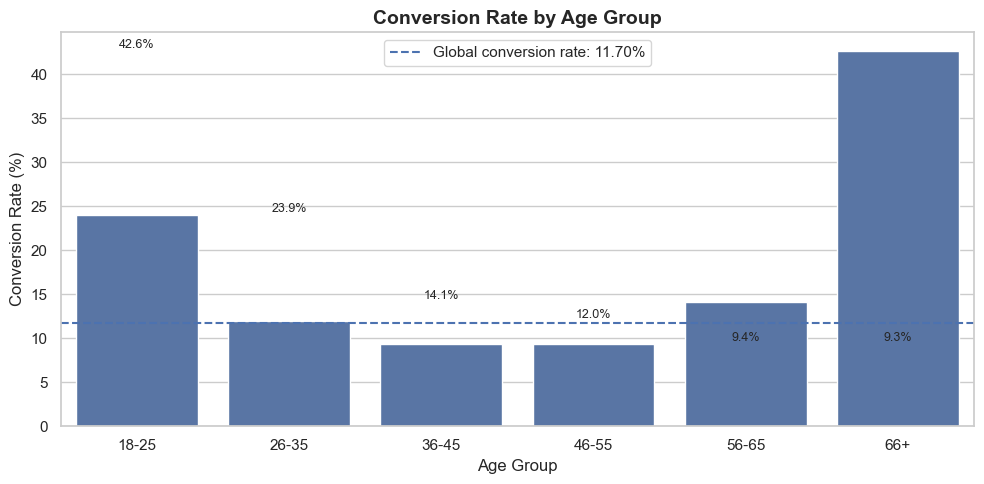

In [20]:
# ============================================================
# 18. CONVERSION RATE BY AGE GROUP
# ============================================================

age_perf = segment_performance_tables["age_group"].copy()
age_perf = age_perf.sort_values("Conversion_Rate", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=age_perf,
    x="age_group",
    y="Conversion_Rate"
)

plt.axhline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate (%)")
plt.legend()

for i, value in enumerate(age_perf["Conversion_Rate"]):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_figure("02_conversion_by_age_group.png")
plt.show()

Figure saved: ..\reports\figures\03_conversion_by_job.png


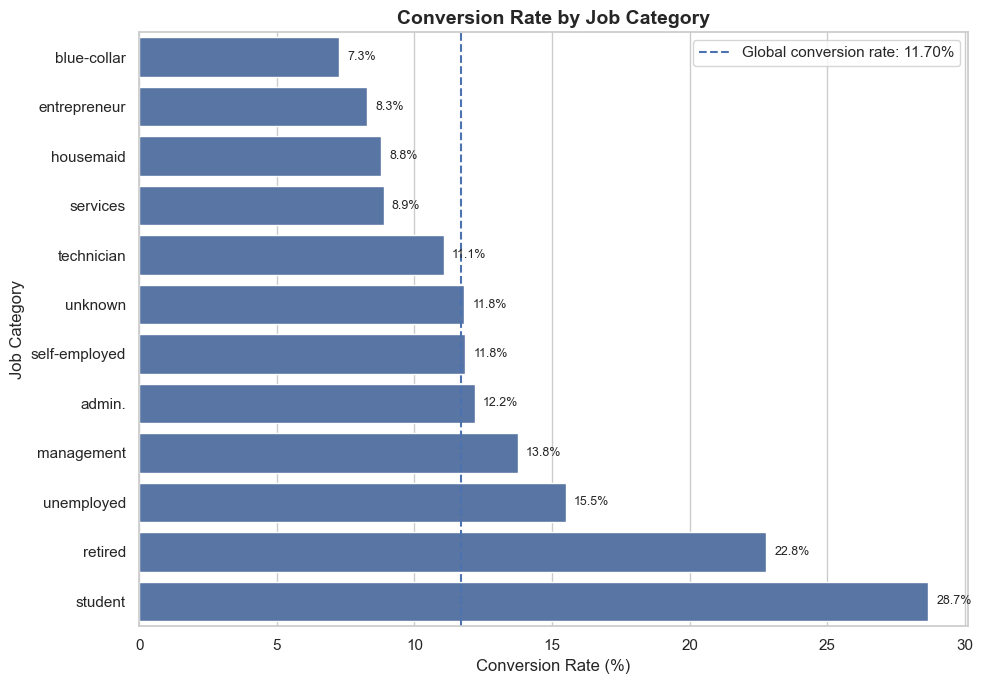

In [21]:
# ============================================================
# 19. CONVERSION RATE BY JOB
# ============================================================

job_perf = segment_performance_tables["job"].copy()
job_perf = job_perf.sort_values("Conversion_Rate", ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=job_perf,
    x="Conversion_Rate",
    y="job"
)

plt.axvline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Job Category", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Job Category")
plt.legend()

for i, value in enumerate(job_perf["Conversion_Rate"]):
    plt.text(value + 0.3, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
save_current_figure("03_conversion_by_job.png")
plt.show()

Figure saved: ..\reports\figures\04_conversion_by_balance_segment.png


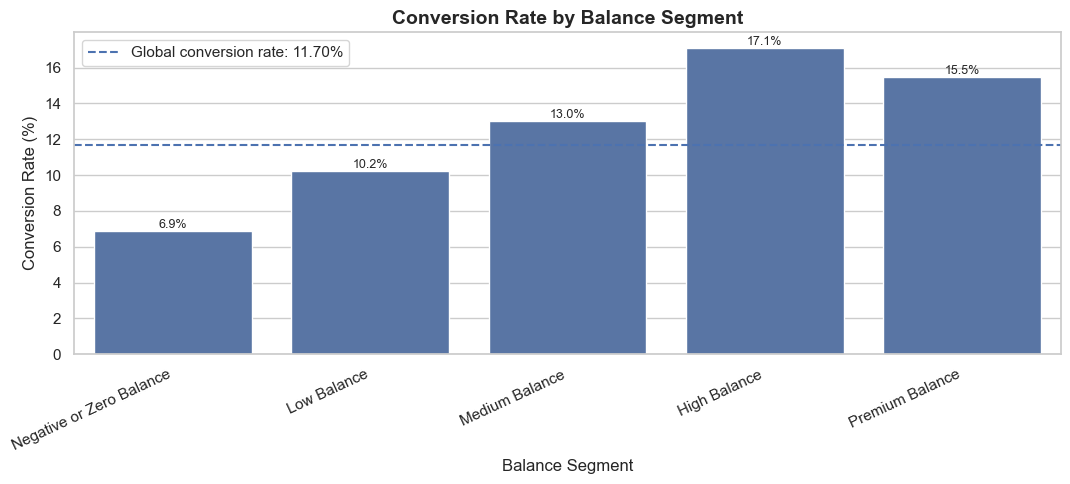

In [22]:
# ============================================================
# 20. CONVERSION RATE BY BALANCE SEGMENT
# ============================================================

balance_perf = segment_performance_tables["balance_segment"].copy()
balance_order = [
    "Negative or Zero Balance",
    "Low Balance",
    "Medium Balance",
    "High Balance",
    "Premium Balance"
]

balance_perf["balance_segment"] = pd.Categorical(
    balance_perf["balance_segment"],
    categories=balance_order,
    ordered=True
)

balance_perf = balance_perf.sort_values("balance_segment")

plt.figure(figsize=(11, 5))
sns.barplot(
    data=balance_perf,
    x="balance_segment",
    y="Conversion_Rate"
)

plt.axhline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Balance Segment", fontsize=14, fontweight="bold")
plt.xlabel("Balance Segment")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.legend()

for i, value in enumerate(balance_perf["Conversion_Rate"]):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_figure("04_conversion_by_balance_segment.png")
plt.show()

Figure saved: ..\reports\figures\05_campaign_fatigue_effect.png


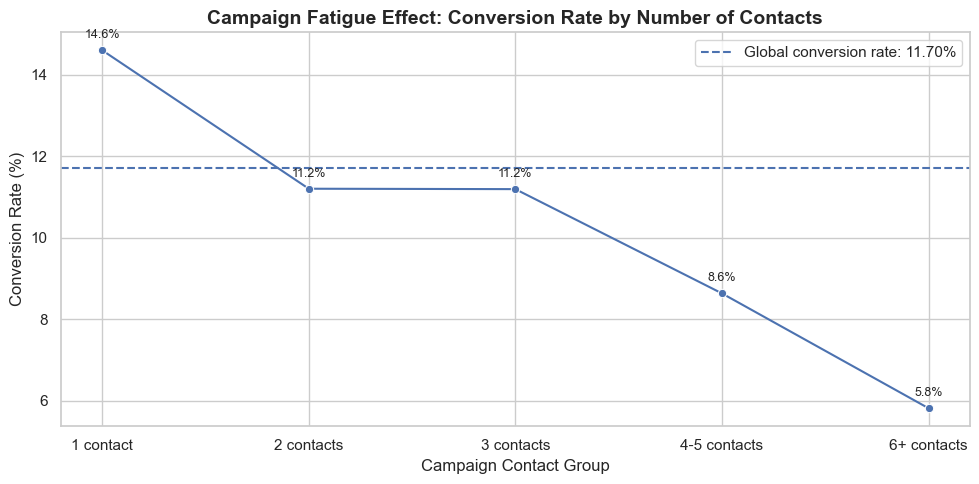

In [23]:
# ============================================================
# 21. CAMPAIGN CONTACT INTENSITY EFFECT
# ============================================================

contact_perf = segment_performance_tables["campaign_contact_group"].copy()

contact_order = [
    "1 contact",
    "2 contacts",
    "3 contacts",
    "4-5 contacts",
    "6+ contacts"
]

contact_perf["campaign_contact_group"] = pd.Categorical(
    contact_perf["campaign_contact_group"],
    categories=contact_order,
    ordered=True
)

contact_perf = contact_perf.sort_values("campaign_contact_group")

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=contact_perf,
    x="campaign_contact_group",
    y="Conversion_Rate",
    marker="o"
)

plt.axhline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Campaign Fatigue Effect: Conversion Rate by Number of Contacts", fontsize=14, fontweight="bold")
plt.xlabel("Campaign Contact Group")
plt.ylabel("Conversion Rate (%)")
plt.legend()

for i, value in enumerate(contact_perf["Conversion_Rate"]):
    plt.text(i, value + 0.3, f"{value:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
save_current_figure("05_campaign_fatigue_effect.png")
plt.show()

Figure saved: ..\reports\figures\06_conversion_by_previous_campaign_outcome.png


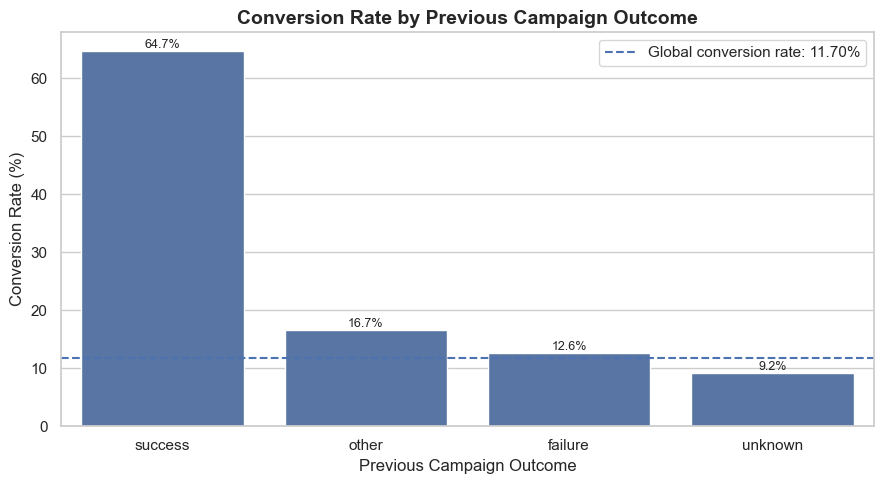

In [24]:
# ============================================================
# 22. PREVIOUS CAMPAIGN OUTCOME IMPACT
# ============================================================

poutcome_perf = segment_performance_tables["poutcome"].copy()
poutcome_perf = poutcome_perf.sort_values("Conversion_Rate", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=poutcome_perf,
    x="poutcome",
    y="Conversion_Rate"
)

plt.axhline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Previous Campaign Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Conversion Rate (%)")
plt.legend()

for i, value in enumerate(poutcome_perf["Conversion_Rate"]):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_figure("06_conversion_by_previous_campaign_outcome.png")
plt.show()

Figure saved: ..\reports\figures\07_conversion_by_loan_profile.png


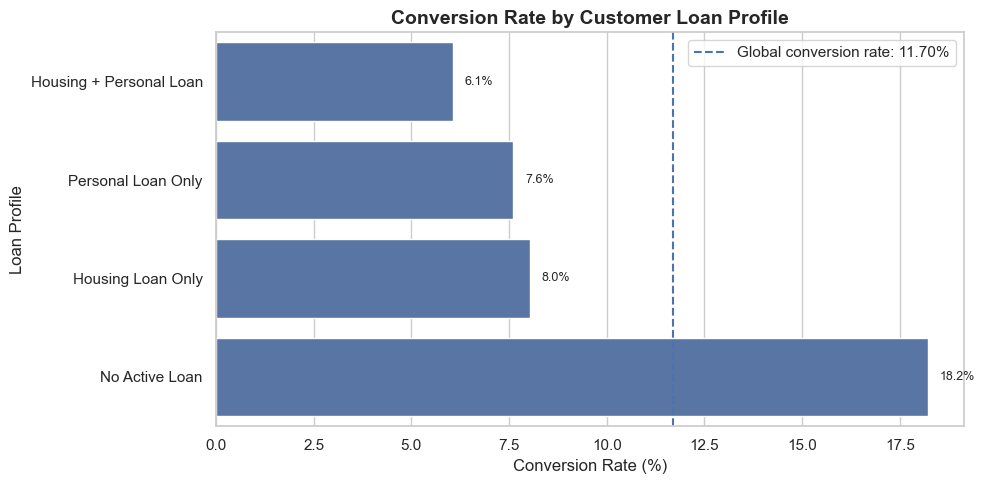

In [25]:
# ============================================================
# 23. CONVERSION RATE BY LOAN PROFILE
# ============================================================

loan_perf = segment_performance_tables["loan_profile"].copy()
loan_perf = loan_perf.sort_values("Conversion_Rate", ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=loan_perf,
    x="Conversion_Rate",
    y="loan_profile"
)

plt.axvline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Customer Loan Profile", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Loan Profile")
plt.legend()

for i, value in enumerate(loan_perf["Conversion_Rate"]):
    plt.text(value + 0.3, i, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
save_current_figure("07_conversion_by_loan_profile.png")
plt.show()

Figure saved: ..\reports\figures\08_conversion_by_month.png


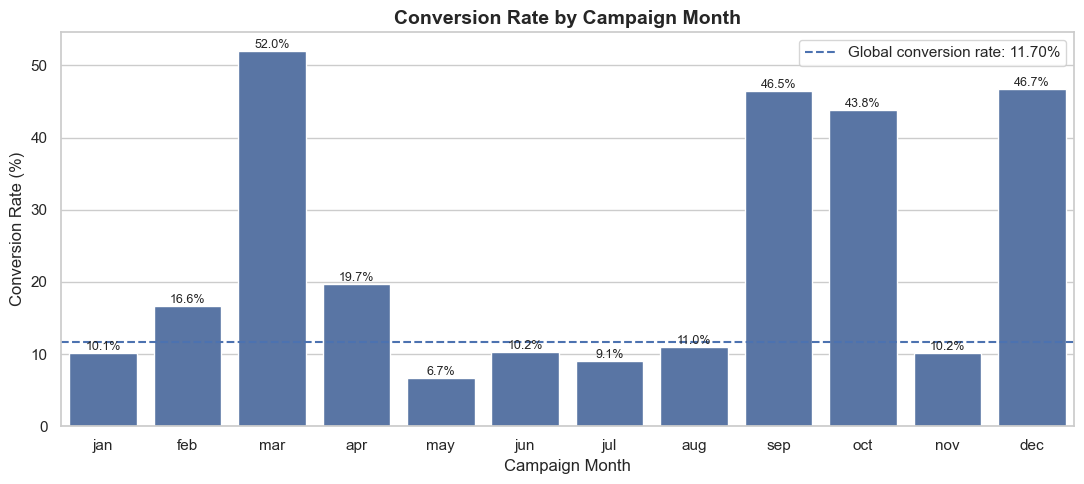

In [26]:
# ============================================================
# 24. CONVERSION RATE BY CAMPAIGN MONTH
# ============================================================

month_perf = segment_performance_tables["month"].copy()

month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_perf["month"] = pd.Categorical(
    month_perf["month"],
    categories=month_order,
    ordered=True
)

month_perf = month_perf.sort_values("month")

plt.figure(figsize=(11, 5))
sns.barplot(
    data=month_perf,
    x="month",
    y="Conversion_Rate"
)

plt.axhline(conversion_rate, linestyle="--", label=f"Global conversion rate: {conversion_rate:.2f}%")

plt.title("Conversion Rate by Campaign Month", fontsize=14, fontweight="bold")
plt.xlabel("Campaign Month")
plt.ylabel("Conversion Rate (%)")
plt.legend()

for i, value in enumerate(month_perf["Conversion_Rate"]):
    plt.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
save_current_figure("08_conversion_by_month.png")
plt.show()

In [27]:
# ============================================================
# 25. SAVE EDA KEY TABLES
# ============================================================

eda_summary_tables = {
    "age_group_performance": age_perf,
    "job_performance": job_perf,
    "balance_segment_performance": balance_perf,
    "campaign_contact_performance": contact_perf,
    "previous_campaign_outcome_performance": poutcome_perf,
    "loan_profile_performance": loan_perf,
    "month_performance": month_perf
}

for table_name, table in eda_summary_tables.items():
    output_path = REPORTS_DIR / f"{table_name}.csv"
    table.to_csv(output_path, index=False)

print("EDA summary tables saved successfully in:", REPORTS_DIR)
print("Figures saved successfully in:", FIGURES_DIR)

EDA summary tables saved successfully in: ..\reports
Figures saved successfully in: ..\reports\figures


# 6. Test & Learn / A-B Test Simulation

This section simulates a Test & Learn analysis by comparing campaign conversion performance between two contact channels.

The objective is to compare:

- Group A: telephone contact;
- Group B: cellular contact.

This is an A/B-style analysis based on historical campaign data. Since customers were not randomly assigned, results should be interpreted as business evidence rather than a strict causal experiment.

In [28]:
# ============================================================
# 26. A/B TEST DATA PREPARATION
# ============================================================

# Keep only known contact channels for A/B-style comparison
ab_data = bank_kpi[bank_kpi["contact"].isin(["telephone", "cellular"])].copy()

# Define A/B groups
ab_data["ab_group"] = ab_data["contact"].map({
    "telephone": "Group A - Telephone",
    "cellular": "Group B - Cellular"
})

print("A/B-style dataset created successfully")
print("Dataset shape:", ab_data.shape)

print("\nA/B group distribution:")
display(ab_data["ab_group"].value_counts())

print("\nConversion by A/B group:")
ab_summary = (
    ab_data
    .groupby("ab_group")
    .agg(
        Clients=("conversion", "count"),
        Converted_Clients=("conversion", "sum"),
        Conversion_Rate=("conversion", "mean"),
        Average_Balance=("balance", "mean"),
        Average_Campaign_Contacts=("campaign", "mean"),
        Average_Call_Duration=("duration", "mean")
    )
    .reset_index()
)

ab_summary["Conversion_Rate"] = (ab_summary["Conversion_Rate"] * 100).round(2)
ab_summary["Average_Balance"] = ab_summary["Average_Balance"].round(2)
ab_summary["Average_Campaign_Contacts"] = ab_summary["Average_Campaign_Contacts"].round(2)
ab_summary["Average_Call_Duration"] = ab_summary["Average_Call_Duration"].round(2)

display(ab_summary)

A/B-style dataset created successfully
Dataset shape: (32191, 28)

A/B group distribution:


ab_group
Group B - Cellular     29285
Group A - Telephone     2906
Name: count, dtype: int64


Conversion by A/B group:


,ab_group,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
0,Group A - Telephone,2906,390,13.4200,"1,803.7000",3.4000,235.3700
1,Group B - Cellular,29285,4369,14.9200,"1,397.9300",2.6900,263.0100


In [29]:
# ============================================================
# 27. TWO-PROPORTION Z-TEST FOR CONVERSION RATE DIFFERENCE
# ============================================================

# Extract group values
group_a = ab_data[ab_data["ab_group"] == "Group A - Telephone"]
group_b = ab_data[ab_data["ab_group"] == "Group B - Cellular"]

n_a = len(group_a)
n_b = len(group_b)

converted_a = group_a["conversion"].sum()
converted_b = group_b["conversion"].sum()

rate_a = converted_a / n_a
rate_b = converted_b / n_b

# Pooled conversion rate
pooled_rate = (converted_a + converted_b) / (n_a + n_b)

# Standard error
standard_error = np.sqrt(
    pooled_rate * (1 - pooled_rate) * (1 / n_a + 1 / n_b)
)

# Z-score
z_score = (rate_b - rate_a) / standard_error

# Two-tailed p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# Difference in percentage points
difference_pp = (rate_b - rate_a) * 100

ab_test_results = pd.DataFrame({
    "Metric": [
        "Group A Clients",
        "Group B Clients",
        "Group A Converted Clients",
        "Group B Converted Clients",
        "Group A Conversion Rate (%)",
        "Group B Conversion Rate (%)",
        "Difference B - A (percentage points)",
        "Z-score",
        "P-value"
    ],
    "Value": [
        n_a,
        n_b,
        converted_a,
        converted_b,
        round(rate_a * 100, 2),
        round(rate_b * 100, 2),
        round(difference_pp, 2),
        round(z_score, 4),
        round(p_value, 6)
    ]
})

print("A/B-style statistical test results:")
display(ab_test_results)

if p_value < 0.05:
    print("\nConclusion: The difference in conversion rate is statistically significant at the 5% level.")
else:
    print("\nConclusion: The difference in conversion rate is not statistically significant at the 5% level.")

A/B-style statistical test results:


,Metric,Value
0,Group A Clients,"2,906.0000"
1,Group B Clients,"29,285.0000"
2,Group A Converted Clients,390.0000
3,Group B Converted Clients,"4,369.0000"
4,Group A Conversion Rate (%),13.4200
5,Group B Conversion Rate (%),14.9200
6,Difference B - A (percentage points),1.5000
7,Z-score,2.1706
8,P-value,0.0300



Conclusion: The difference in conversion rate is statistically significant at the 5% level.


Figure saved: ..\reports\figures\09_ab_test_contact_channel.png


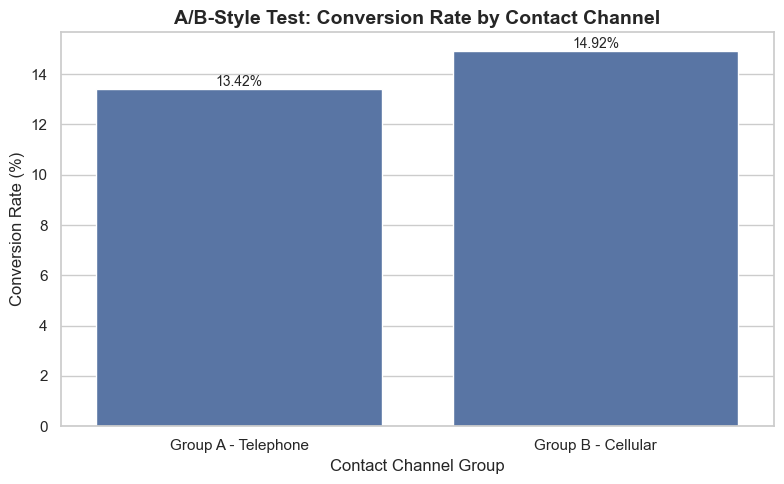

In [30]:
# ============================================================
# 28. A/B TEST VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=ab_summary,
    x="ab_group",
    y="Conversion_Rate"
)

plt.title("A/B-Style Test: Conversion Rate by Contact Channel", fontsize=14, fontweight="bold")
plt.xlabel("Contact Channel Group")
plt.ylabel("Conversion Rate (%)")

for i, value in enumerate(ab_summary["Conversion_Rate"]):
    plt.text(i, value, f"{value:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
save_current_figure("09_ab_test_contact_channel.png")
plt.show()

In [31]:
# ============================================================
# 29. A/B TEST BUSINESS INTERPRETATION
# ============================================================

if rate_b > rate_a:
    winning_group = "Group B - Cellular"
    losing_group = "Group A - Telephone"
else:
    winning_group = "Group A - Telephone"
    losing_group = "Group B - Cellular"

ab_interpretation = {
    "Winning Group": winning_group,
    "Lower Performing Group": losing_group,
    "Conversion Rate Difference (pp)": round(abs(difference_pp), 2),
    "Statistically Significant": "Yes" if p_value < 0.05 else "No",
    "Business Interpretation": (
        f"{winning_group} shows a higher conversion rate than {losing_group}. "
        "This suggests that contact channel selection can influence campaign performance. "
        "However, since this is an observational historical dataset and not a randomized experiment, "
        "the result should be used as Test & Learn evidence rather than strict causal proof."
    )
}

ab_interpretation_df = pd.DataFrame(
    list(ab_interpretation.items()),
    columns=["Item", "Interpretation"]
)

display(ab_interpretation_df)

# Save A/B test results
ab_summary_path = REPORTS_DIR / "ab_test_contact_channel_summary.csv"
ab_test_results_path = REPORTS_DIR / "ab_test_statistical_results.csv"
ab_interpretation_path = REPORTS_DIR / "ab_test_business_interpretation.csv"

ab_summary.to_csv(ab_summary_path, index=False)
ab_test_results.to_csv(ab_test_results_path, index=False)
ab_interpretation_df.to_csv(ab_interpretation_path, index=False)

print("A/B test outputs saved successfully:")
print("-", ab_summary_path)
print("-", ab_test_results_path)
print("-", ab_interpretation_path)

,Item,Interpretation
0,Winning Group,Group B - Cellular
1,Lower Performing Group,Group A - Telephone
2,Conversion Rate Difference (pp),1.5000
3,Statistically Significant,Yes
4,Business Interpretation,Group B - Cellular shows a higher conversion r...


A/B test outputs saved successfully:
- ..\reports\ab_test_contact_channel_summary.csv
- ..\reports\ab_test_statistical_results.csv
- ..\reports\ab_test_business_interpretation.csv


# 7. Automated HTML Dashboard

This section generates an automated HTML dashboard using Plotly.

The dashboard summarizes:

- global campaign KPIs;
- conversion performance by age group;
- conversion performance by job category;
- conversion performance by balance segment;
- campaign fatigue effect;
- previous campaign outcome impact;
- A/B-style contact channel comparison;
- business recommendations.

In [32]:
# ============================================================
# 30. DASHBOARD DATA PREPARATION
# ============================================================

# Prepare main tables for dashboard
dashboard_global_kpis = global_kpis.copy()

dashboard_age = segment_performance_tables["age_group"].copy()
dashboard_job = segment_performance_tables["job"].copy()
dashboard_balance = segment_performance_tables["balance_segment"].copy()
dashboard_campaign_contacts = segment_performance_tables["campaign_contact_group"].copy()
dashboard_poutcome = segment_performance_tables["poutcome"].copy()
dashboard_loan = segment_performance_tables["loan_profile"].copy()
dashboard_month = segment_performance_tables["month"].copy()

print("Dashboard data prepared successfully")

print("Global KPIs:")
display(dashboard_global_kpis)

print("A/B summary:")
display(ab_summary)

Dashboard data prepared successfully
Global KPIs:


,KPI,Value
0,Total Clients,"45,211.0000"
1,Converted Clients,"5,289.0000"
2,Not Converted Clients,"39,922.0000"
3,Conversion Rate (%),11.7000
4,Average Balance,"1,362.2700"
5,Median Balance,448.0000
6,Average Campaign Contacts,2.7600
7,Median Campaign Contacts,2.0000
8,Average Call Duration (sec),258.1600
9,Median Call Duration (sec),180.0000


A/B summary:


,ab_group,Clients,Converted_Clients,Conversion_Rate,Average_Balance,Average_Campaign_Contacts,Average_Call_Duration
0,Group A - Telephone,2906,390,13.4200,"1,803.7000",3.4000,235.3700
1,Group B - Cellular,29285,4369,14.9200,"1,397.9300",2.6900,263.0100


In [33]:
# ============================================================
# 31. PLOTLY DASHBOARD CHARTS
# ============================================================

# Global conversion distribution
conversion_counts_df = (
    bank_kpi["conversion_label"]
    .value_counts()
    .reset_index()
)

conversion_counts_df.columns = ["Conversion_Status", "Clients"]

fig_conversion = px.bar(
    conversion_counts_df,
    x="Conversion_Status",
    y="Clients",
    text="Clients",
    title="Global Campaign Conversion Distribution"
)

fig_conversion.update_traces(texttemplate="%{text:,}", textposition="outside")
fig_conversion.update_layout(
    xaxis_title="Conversion Status",
    yaxis_title="Number of Clients"
)

# Conversion by age group
dashboard_age_sorted = dashboard_age.sort_values("Conversion_Rate", ascending=False)

fig_age = px.bar(
    dashboard_age_sorted,
    x="age_group",
    y="Conversion_Rate",
    text="Conversion_Rate",
    title="Conversion Rate by Age Group"
)

fig_age.add_hline(
    y=conversion_rate,
    line_dash="dash",
    annotation_text=f"Global rate: {conversion_rate:.2f}%"
)

fig_age.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig_age.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Conversion Rate (%)"
)

# Conversion by job
dashboard_job_sorted = dashboard_job.sort_values("Conversion_Rate", ascending=True)

fig_job = px.bar(
    dashboard_job_sorted,
    x="Conversion_Rate",
    y="job",
    orientation="h",
    text="Conversion_Rate",
    title="Conversion Rate by Job Category"
)

fig_job.add_vline(
    x=conversion_rate,
    line_dash="dash",
    annotation_text=f"Global rate: {conversion_rate:.2f}%"
)

fig_job.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig_job.update_layout(
    xaxis_title="Conversion Rate (%)",
    yaxis_title="Job Category"
)

# Conversion by balance segment
balance_order = [
    "Negative or Zero Balance",
    "Low Balance",
    "Medium Balance",
    "High Balance",
    "Premium Balance"
]

dashboard_balance["balance_segment"] = pd.Categorical(
    dashboard_balance["balance_segment"],
    categories=balance_order,
    ordered=True
)

dashboard_balance_sorted = dashboard_balance.sort_values("balance_segment")

fig_balance = px.bar(
    dashboard_balance_sorted,
    x="balance_segment",
    y="Conversion_Rate",
    text="Conversion_Rate",
    title="Conversion Rate by Balance Segment"
)

fig_balance.add_hline(
    y=conversion_rate,
    line_dash="dash",
    annotation_text=f"Global rate: {conversion_rate:.2f}%"
)

fig_balance.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig_balance.update_layout(
    xaxis_title="Balance Segment",
    yaxis_title="Conversion Rate (%)"
)

# Campaign fatigue effect
contact_order = [
    "1 contact",
    "2 contacts",
    "3 contacts",
    "4-5 contacts",
    "6+ contacts"
]

dashboard_campaign_contacts["campaign_contact_group"] = pd.Categorical(
    dashboard_campaign_contacts["campaign_contact_group"],
    categories=contact_order,
    ordered=True
)

dashboard_campaign_contacts_sorted = dashboard_campaign_contacts.sort_values(
    "campaign_contact_group"
)

fig_contacts = px.line(
    dashboard_campaign_contacts_sorted,
    x="campaign_contact_group",
    y="Conversion_Rate",
    markers=True,
    text="Conversion_Rate",
    title="Campaign Fatigue Effect: Conversion Rate by Number of Contacts"
)

fig_contacts.add_hline(
    y=conversion_rate,
    line_dash="dash",
    annotation_text=f"Global rate: {conversion_rate:.2f}%"
)

fig_contacts.update_traces(texttemplate="%{text:.1f}%", textposition="top center")
fig_contacts.update_layout(
    xaxis_title="Campaign Contact Group",
    yaxis_title="Conversion Rate (%)"
)

# Previous campaign outcome
dashboard_poutcome_sorted = dashboard_poutcome.sort_values(
    "Conversion_Rate",
    ascending=False
)

fig_poutcome = px.bar(
    dashboard_poutcome_sorted,
    x="poutcome",
    y="Conversion_Rate",
    text="Conversion_Rate",
    title="Conversion Rate by Previous Campaign Outcome"
)

fig_poutcome.add_hline(
    y=conversion_rate,
    line_dash="dash",
    annotation_text=f"Global rate: {conversion_rate:.2f}%"
)

fig_poutcome.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig_poutcome.update_layout(
    xaxis_title="Previous Campaign Outcome",
    yaxis_title="Conversion Rate (%)"
)

# A/B test chart
fig_ab = px.bar(
    ab_summary,
    x="ab_group",
    y="Conversion_Rate",
    text="Conversion_Rate",
    title="A/B-Style Test: Conversion Rate by Contact Channel"
)

fig_ab.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
fig_ab.update_layout(
    xaxis_title="Contact Channel",
    yaxis_title="Conversion Rate (%)"
)

print("Plotly dashboard charts created successfully")

Plotly dashboard charts created successfully


In [34]:
# ============================================================
# 32. KPI CARDS HTML
# ============================================================

def get_kpi_value(kpi_name):
    return dashboard_global_kpis.loc[
        dashboard_global_kpis["KPI"] == kpi_name,
        "Value"
    ].iloc[0]

total_clients_card = int(get_kpi_value("Total Clients"))
converted_clients_card = int(get_kpi_value("Converted Clients"))
conversion_rate_card = get_kpi_value("Conversion Rate (%)")
avg_balance_card = get_kpi_value("Average Balance")
avg_contacts_card = get_kpi_value("Average Campaign Contacts")
previous_contacted_card = get_kpi_value("Previously Contacted Clients (%)")

kpi_cards_html = f"""
<div class="kpi-grid">
    <div class="kpi-card">
        <div class="kpi-title">Total Clients</div>
        <div class="kpi-value">{total_clients_card:,}</div>
    </div>
    <div class="kpi-card">
        <div class="kpi-title">Converted Clients</div>
        <div class="kpi-value">{converted_clients_card:,}</div>
    </div>
    <div class="kpi-card">
        <div class="kpi-title">Conversion Rate</div>
        <div class="kpi-value">{conversion_rate_card:.2f}%</div>
    </div>
    <div class="kpi-card">
        <div class="kpi-title">Average Balance</div>
        <div class="kpi-value">{avg_balance_card:,.0f}</div>
    </div>
    <div class="kpi-card">
        <div class="kpi-title">Average Contacts</div>
        <div class="kpi-value">{avg_contacts_card:.2f}</div>
    </div>
    <div class="kpi-card">
        <div class="kpi-title">Previously Contacted</div>
        <div class="kpi-value">{previous_contacted_card:.2f}%</div>
    </div>
</div>
"""

print("KPI cards created successfully")

KPI cards created successfully


In [35]:
# ============================================================
# 33. GENERATE AUTOMATED HTML DASHBOARD
# ============================================================

# Convert Plotly figures to HTML snippets
fig_conversion_html = fig_conversion.to_html(full_html=False, include_plotlyjs="cdn")
fig_age_html = fig_age.to_html(full_html=False, include_plotlyjs=False)
fig_job_html = fig_job.to_html(full_html=False, include_plotlyjs=False)
fig_balance_html = fig_balance.to_html(full_html=False, include_plotlyjs=False)
fig_contacts_html = fig_contacts.to_html(full_html=False, include_plotlyjs=False)
fig_poutcome_html = fig_poutcome.to_html(full_html=False, include_plotlyjs=False)
fig_ab_html = fig_ab.to_html(full_html=False, include_plotlyjs=False)

# Key insights
business_recommendations = """
<ul>
    <li><strong>Prioritize clients with previous campaign success:</strong> this segment shows the highest conversion rate.</li>
    <li><strong>Focus on high-performing customer profiles:</strong> students, retired clients, seniors, and young adults show above-average conversion.</li>
    <li><strong>Target financially stronger clients:</strong> medium, high, and premium balance segments outperform low and negative-balance clients.</li>
    <li><strong>Reduce excessive contact attempts:</strong> conversion decreases sharply after repeated contacts, indicating campaign fatigue.</li>
    <li><strong>Prefer cellular contact channel:</strong> the A/B-style analysis shows a statistically significant higher conversion rate for cellular contact.</li>
    <li><strong>Use seasonal planning:</strong> some months show stronger conversion and should be investigated for campaign timing optimization.</li>
</ul>
"""

dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Banking Customer Campaign Performance Dashboard</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            background-color: #f5f7fb;
            color: #1f2937;
        }}
        .header {{
            background: linear-gradient(135deg, #0f172a, #1e3a8a);
            color: white;
            padding: 35px 50px;
        }}
        .header h1 {{
            margin: 0;
            font-size: 32px;
        }}
        .header p {{
            margin-top: 10px;
            font-size: 16px;
            color: #dbeafe;
        }}
        .section {{
            margin: 25px 50px;
            background-color: white;
            padding: 25px;
            border-radius: 14px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.06);
        }}
        .section h2 {{
            margin-top: 0;
            color: #111827;
            border-left: 5px solid #1e3a8a;
            padding-left: 12px;
        }}
        .kpi-grid {{
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 18px;
            margin-top: 20px;
        }}
        .kpi-card {{
            background: #eff6ff;
            padding: 22px;
            border-radius: 12px;
            border-left: 5px solid #2563eb;
        }}
        .kpi-title {{
            font-size: 14px;
            color: #475569;
            margin-bottom: 8px;
        }}
        .kpi-value {{
            font-size: 28px;
            font-weight: bold;
            color: #0f172a;
        }}
        .insight-box {{
            background-color: #f8fafc;
            border-left: 5px solid #16a34a;
            padding: 18px;
            border-radius: 10px;
            line-height: 1.6;
        }}
        .footer {{
            margin: 30px 50px;
            color: #64748b;
            font-size: 13px;
            text-align: center;
        }}
    </style>
</head>
<body>

<div class="header">
    <h1>Banking Customer Campaign Performance Dashboard</h1>
    <p>Automated Data Analyst dashboard for banking campaign KPI monitoring, customer segmentation, Test & Learn analysis, and business decision support.</p>
</div>

<div class="section">
    <h2>Executive KPI Overview</h2>
    {kpi_cards_html}
</div>

<div class="section">
    <h2>Global Campaign Conversion</h2>
    {fig_conversion_html}
</div>

<div class="section">
    <h2>Customer Segmentation Performance</h2>
    {fig_age_html}
    {fig_job_html}
    {fig_balance_html}
</div>

<div class="section">
    <h2>Campaign Performance Analysis</h2>
    {fig_contacts_html}
    {fig_poutcome_html}
</div>

<div class="section">
    <h2>Test & Learn / A-B Style Analysis</h2>
    {fig_ab_html}
</div>

<div class="section">
    <h2>Business Recommendations</h2>
    <div class="insight-box">
        {business_recommendations}
    </div>
</div>

<div class="footer">
    Generated automatically with Python, Pandas and Plotly | Author: Chanez Benidir
</div>

</body>
</html>
"""

dashboard_path = DASHBOARD_DIR / "banking_campaign_dashboard.html"

with open(dashboard_path, "w", encoding="utf-8") as file:
    file.write(dashboard_html)

print("Automated HTML dashboard generated successfully")
print("Dashboard path:", dashboard_path)

Automated HTML dashboard generated successfully
Dashboard path: ..\dashboard\banking_campaign_dashboard.html


In [36]:
# ============================================================
# 33. GENERATE AUTOMATED HTML DASHBOARD
# ============================================================

# Convert Plotly figures to HTML snippets
fig_conversion_html = fig_conversion.to_html(full_html=False, include_plotlyjs="cdn")
fig_age_html = fig_age.to_html(full_html=False, include_plotlyjs=False)
fig_job_html = fig_job.to_html(full_html=False, include_plotlyjs=False)
fig_balance_html = fig_balance.to_html(full_html=False, include_plotlyjs=False)
fig_contacts_html = fig_contacts.to_html(full_html=False, include_plotlyjs=False)
fig_poutcome_html = fig_poutcome.to_html(full_html=False, include_plotlyjs=False)
fig_ab_html = fig_ab.to_html(full_html=False, include_plotlyjs=False)

business_recommendations = """
<ul>
    <li><strong>Prioritize clients with previous campaign success:</strong> this segment shows the highest conversion rate.</li>
    <li><strong>Focus on high-performing customer profiles:</strong> students, retired clients, seniors, and young adults show above-average conversion.</li>
    <li><strong>Target financially stronger clients:</strong> medium, high, and premium balance segments outperform low and negative-balance clients.</li>
    <li><strong>Reduce excessive contact attempts:</strong> conversion decreases sharply after repeated contacts, indicating campaign fatigue.</li>
    <li><strong>Prefer cellular contact channel:</strong> the A/B-style analysis shows a statistically significant higher conversion rate for cellular contact.</li>
    <li><strong>Use seasonal planning:</strong> some months show stronger conversion and should be investigated for campaign timing optimization.</li>
</ul>
"""

dashboard_html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Banking Customer Campaign Performance Dashboard</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            background-color: #f5f7fb;
            color: #1f2937;
        }}
        .header {{
            background: linear-gradient(135deg, #0f172a, #1e3a8a);
            color: white;
            padding: 35px 50px;
        }}
        .header h1 {{
            margin: 0;
            font-size: 32px;
        }}
        .header p {{
            margin-top: 10px;
            font-size: 16px;
            color: #dbeafe;
        }}
        .section {{
            margin: 25px 50px;
            background-color: white;
            padding: 25px;
            border-radius: 14px;
            box-shadow: 0 4px 12px rgba(0,0,0,0.06);
        }}
        .section h2 {{
            margin-top: 0;
            color: #111827;
            border-left: 5px solid #1e3a8a;
            padding-left: 12px;
        }}
        .kpi-grid {{
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 18px;
            margin-top: 20px;
        }}
        .kpi-card {{
            background: #eff6ff;
            padding: 22px;
            border-radius: 12px;
            border-left: 5px solid #2563eb;
        }}
        .kpi-title {{
            font-size: 14px;
            color: #475569;
            margin-bottom: 8px;
        }}
        .kpi-value {{
            font-size: 28px;
            font-weight: bold;
            color: #0f172a;
        }}
        .insight-box {{
            background-color: #f8fafc;
            border-left: 5px solid #16a34a;
            padding: 18px;
            border-radius: 10px;
            line-height: 1.6;
        }}
        .footer {{
            margin: 30px 50px;
            color: #64748b;
            font-size: 13px;
            text-align: center;
        }}
    </style>
</head>
<body>

<div class="header">
    <h1>Banking Customer Campaign Performance Dashboard</h1>
    <p>Automated Data Analyst dashboard for banking campaign KPI monitoring, customer segmentation, Test & Learn analysis, and business decision support.</p>
</div>

<div class="section">
    <h2>Executive KPI Overview</h2>
    {kpi_cards_html}
</div>

<div class="section">
    <h2>Global Campaign Conversion</h2>
    {fig_conversion_html}
</div>

<div class="section">
    <h2>Customer Segmentation Performance</h2>
    {fig_age_html}
    {fig_job_html}
    {fig_balance_html}
</div>

<div class="section">
    <h2>Campaign Performance Analysis</h2>
    {fig_contacts_html}
    {fig_poutcome_html}
</div>

<div class="section">
    <h2>Test & Learn / A-B Style Analysis</h2>
    {fig_ab_html}
</div>

<div class="section">
    <h2>Business Recommendations</h2>
    <div class="insight-box">
        {business_recommendations}
    </div>
</div>

<div class="footer">
    Generated automatically with Python, Pandas and Plotly | Author: Chanez Benidir
</div>

</body>
</html>
"""

dashboard_path = DASHBOARD_DIR / "banking_campaign_dashboard.html"

with open(dashboard_path, "w", encoding="utf-8") as file:
    file.write(dashboard_html)

print("Automated HTML dashboard generated successfully")
print("Dashboard path:", dashboard_path)

Automated HTML dashboard generated successfully
Dashboard path: ..\dashboard\banking_campaign_dashboard.html


# 8. Automated Excel KPI Report

This section generates an automated Excel report containing the main banking KPIs, customer segmentation results, campaign performance analysis, Test & Learn results, and business recommendations.

The objective is to create a professional reporting output that can be shared with business teams and management.

In [38]:
# ============================================================
# 34. GENERATE AUTOMATED EXCEL KPI REPORT
# ============================================================

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

excel_report_path = REPORTS_DIR / "banking_kpi_report.xlsx"

# Prepare recommendations table
recommendations_df = pd.DataFrame({
    "Recommendation": [
        "Prioritize clients with previous campaign success",
        "Focus on students, retired clients, seniors, and young adults",
        "Target medium, high, and premium balance customers",
        "Reduce excessive contact attempts",
        "Prefer cellular contact channel",
        "Analyze seasonal campaign performance"
    ],
    "Business Rationale": [
        "Clients with previous success show the highest conversion rate.",
        "These customer profiles show above-average conversion rates.",
        "Financially stronger clients convert better than low or negative-balance clients.",
        "Conversion decreases sharply after repeated contacts, indicating campaign fatigue.",
        "Cellular contact shows a higher and statistically significant conversion rate than telephone.",
        "Some months show much higher conversion and should guide campaign planning."
    ],
    "Suggested Action": [
        "Create a priority targeting list for clients with successful previous campaigns.",
        "Design tailored offers for students and retired clients.",
        "Prioritize financially stable clients in commercial campaigns.",
        "Limit repeated contacts and improve targeting quality.",
        "Use cellular as the preferred channel and confirm with a controlled A/B test.",
        "Plan campaigns around high-performing months while checking contact volumes."
    ]
})

# Write Excel file
with pd.ExcelWriter(excel_report_path, engine="openpyxl") as writer:
    global_kpis.to_excel(writer, sheet_name="Executive KPIs", index=False)
    segment_performance_tables["age_group"].to_excel(writer, sheet_name="Age Performance", index=False)
    segment_performance_tables["job"].to_excel(writer, sheet_name="Job Performance", index=False)
    segment_performance_tables["balance_segment"].to_excel(writer, sheet_name="Balance Performance", index=False)
    segment_performance_tables["campaign_contact_group"].to_excel(writer, sheet_name="Campaign Contacts", index=False)
    segment_performance_tables["poutcome"].to_excel(writer, sheet_name="Previous Outcome", index=False)
    segment_performance_tables["loan_profile"].to_excel(writer, sheet_name="Loan Profile", index=False)
    segment_performance_tables["month"].to_excel(writer, sheet_name="Month Performance", index=False)
    ab_summary.to_excel(writer, sheet_name="AB Test Summary", index=False)
    ab_test_results.to_excel(writer, sheet_name="AB Test Stats", index=False)
    recommendations_df.to_excel(writer, sheet_name="Recommendations", index=False)

print("Excel report created successfully at:", excel_report_path)

Excel report created successfully at: ..\reports\banking_kpi_report.xlsx


In [39]:
# ============================================================
# 35. FORMAT EXCEL KPI REPORT
# ============================================================

workbook = load_workbook(excel_report_path)

# Style definitions
header_fill = PatternFill(start_color="1E3A8A", end_color="1E3A8A", fill_type="solid")
header_font = Font(color="FFFFFF", bold=True)
title_font = Font(bold=True, size=13, color="1E3A8A")
thin_border = Border(
    left=Side(style="thin", color="D9E2F3"),
    right=Side(style="thin", color="D9E2F3"),
    top=Side(style="thin", color="D9E2F3"),
    bottom=Side(style="thin", color="D9E2F3")
)

for sheet_name in workbook.sheetnames:
    worksheet = workbook[sheet_name]
    
    # Freeze header row
    worksheet.freeze_panes = "A2"
    
    # Style header row
    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center")
        cell.border = thin_border
    
    # Style all cells
    for row in worksheet.iter_rows(min_row=2):
        for cell in row:
            cell.border = thin_border
            cell.alignment = Alignment(vertical="center")
    
    # Auto-adjust column widths
    for column_cells in worksheet.columns:
        max_length = 0
        column_letter = get_column_letter(column_cells[0].column)
        
        for cell in column_cells:
            try:
                cell_length = len(str(cell.value))
                if cell_length > max_length:
                    max_length = cell_length
            except:
                pass
        
        adjusted_width = min(max_length + 3, 45)
        worksheet.column_dimensions[column_letter].width = adjusted_width

workbook.save(excel_report_path)

print("Excel report formatted successfully")
print("Final Excel report path:", excel_report_path)

Excel report formatted successfully
Final Excel report path: ..\reports\banking_kpi_report.xlsx


# 9. Final Executive Summary

This section generates a final executive summary containing the main KPIs, analytical findings, Test & Learn results, and business recommendations.

In [40]:
# ============================================================
# 36. GENERATE FINAL EXECUTIVE SUMMARY
# ============================================================

executive_summary = f"""
# Banking Customer Campaign Performance Analytics - Executive Summary

## Project Objective

This project analyzes a retail banking marketing campaign dataset to support business decision-making through KPI monitoring, customer segmentation, campaign performance analysis, Test & Learn methodology, and automated reporting.

The objective is to identify high-performing customer segments, evaluate campaign efficiency, and propose actionable recommendations for banking marketing and commercial teams.

---

## Global Campaign Performance

| KPI | Value |
|---|---:|
| Total Clients | {total_clients:,} |
| Converted Clients | {converted_clients:,} |
| Not Converted Clients | {not_converted_clients:,} |
| Global Conversion Rate | {conversion_rate:.2f}% |
| Average Balance | {average_balance:,.2f} |
| Median Balance | {median_balance:,.2f} |
| Average Campaign Contacts | {average_campaign_contacts:.2f} |
| Previously Contacted Clients | {previously_contacted_rate:.2f}% |

The global campaign conversion rate is **{conversion_rate:.2f}%**, meaning that approximately 12 out of every 100 contacted clients accepted the banking offer.

---

## Key Business Insights

### 1. Customer Age Segmentation

The highest conversion rates are observed among:

- clients aged 66+;
- young adults aged 18-25;
- clients aged 56-65.

This suggests that age-based segmentation can improve campaign targeting.

### 2. Job Category Performance

The strongest job categories are:

- students;
- retired clients;
- unemployed clients;
- management profiles.

These groups show above-average conversion rates and should be considered priority segments for tailored offers.

### 3. Financial Profile

Customers with medium, high, and premium balances convert better than customers with low or negative balances.

This indicates that balance level is an important indicator of commercial potential.

### 4. Campaign Fatigue

The conversion rate decreases as the number of campaign contacts increases.

Clients contacted only once show the best performance, while clients contacted six or more times show the lowest conversion rate.

This suggests that excessive contact attempts can reduce campaign effectiveness.

### 5. Previous Campaign Outcome

Clients with a successful previous campaign outcome show the strongest conversion performance.

This makes previous campaign history one of the most powerful targeting indicators.

### 6. Loan Profile

Clients with no active loan convert better than clients with housing loans, personal loans, or both.

This suggests that customers already engaged in credit commitments may be less responsive to new offers.

---

## Test & Learn / A-B Style Analysis

An A/B-style analysis was performed to compare two contact channels:

- Group A: Telephone
- Group B: Cellular

| Metric | Telephone | Cellular |
|---|---:|---:|
| Clients | {n_a:,} | {n_b:,} |
| Converted Clients | {converted_a:,} | {converted_b:,} |
| Conversion Rate | {rate_a * 100:.2f}% | {rate_b * 100:.2f}% |

The cellular channel achieved a higher conversion rate than the telephone channel.

The difference is **{difference_pp:.2f} percentage points**, with a p-value of **{p_value:.4f}**.

Since the p-value is below 0.05, the difference is statistically significant at the 5% level.

However, since this is based on historical observational data and not a randomized experiment, the result should be interpreted as Test & Learn evidence rather than strict causal proof.

---

## Business Recommendations

1. Prioritize clients with previous campaign success.
2. Focus on high-performing segments such as students, retired clients, seniors, and young adults.
3. Target customers with medium, high, and premium account balances.
4. Reduce excessive repeated contacts to avoid campaign fatigue.
5. Prefer cellular contact for future campaigns, while confirming with a controlled A/B test.
6. Monitor conversion rate by month to improve campaign timing.
7. Build recurring KPI dashboards for marketing and commercial teams.

---

## Deliverables

This project generated:

- a clean analytical dataset;
- business KPI tables;
- customer segmentation analysis;
- campaign performance analysis;
- A/B-style Test & Learn results;
- automated HTML dashboard;
- automated Excel KPI report;
- executive business summary.

---

## Author

Chanez Benidir  
Data Science and Statistics student interested in data analytics, banking performance, KPI monitoring, and business decision support.
"""

executive_summary_path = REPORTS_DIR / "executive_summary.md"

with open(executive_summary_path, "w", encoding="utf-8") as file:
    file.write(executive_summary)

print("Executive summary generated successfully")
print("Executive summary path:", executive_summary_path)

Executive summary generated successfully
Executive summary path: ..\reports\executive_summary.md
